# Urdu Hate Speech Detection
   

> **Paper:** Hussain et al. (2025) *"Enhancing Urdu hate speech detection through differential transfer learning and adaptive loss functions"*, Scientific Reports.  
> DOI: https://doi.org/10.1038/s41598-025-21306-w  

### Models implemented
| Category | Models |
|----------|--------|
| Classical ML | Logistic Regression, SVM, Random Forest |
| Naive Bayes | Multinomial NB, Complement NB, Bernoulli NB |
| Deep Learning | RNN, LSTM |
| Transformer | XLM-RoBERTa |


---
## Phase 0 — Environment & imports

In [4]:
# Install dependencies (uncomment if needed)
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib torch transformers datasets

import random, os, warnings, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"SEED = {SEED} | Device = {DEVICE} | Environment ready.")


SEED = 42 | Device = cuda | Environment ready.


---
## Phase 1 — Data loading & exploration

In [5]:
df = pd.read_csv('Urdu_combined.csv')
print(f"Raw shape: {df.shape}")
print(f"Columns  : {df.columns.tolist()}")
print(df.head(3).to_string())


Raw shape: (16342, 2)
Columns  : ['Comments', 'Label']
                           Comments      Label
0  یہ عمر گانڈوں کی گانڈ مار کر گیا  offensive
1              انسان بن بغیرت نہ بن  offensive
2                    تو خد بغیرت ھے  offensive


In [6]:
# Fix dirty labels & null rows
df.loc[df['Label'].isin(['n']), 'Label'] = 'normal'
df.loc[df['Label'] == 'm',     'Label'] = 'normal'
df = df.dropna(subset=['Comments', 'Label']).reset_index(drop=True)
print(f"After fixing typos & nulls : {df.shape}")

#  Remove duplicates
before = len(df)
df = df.drop_duplicates(subset='Comments').reset_index(drop=True)
print(f"After removing duplicates  : {df.shape}  (removed {before - len(df)})")

#  Remove very short texts (<=2 words, likely noise)
before = len(df)
df = df[df['Comments'].str.split().str.len() > 2].reset_index(drop=True)
print(f"After removing short texts : {df.shape}  (removed {before - len(df)})")

#  Clean label column
valid_labels = {'hate', 'offensive', 'normal'}
df = df[df['Label'].isin(valid_labels)].copy()
df.columns = ['text', 'label']
df = df.dropna(subset=['text','label']).reset_index(drop=True)

label_map  = {'normal': 0, 'offensive': 1, 'hate': 2}
idx_to_lbl = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}
df['label_id'] = df['label'].map(label_map)

print(f"\nFinal clean shape: {df.shape}")
print("\nClass distribution:")
counts = df['label'].value_counts()
print(counts.to_string())
print(f"\nImbalance ratio (max/min): {counts.max()/counts.min():.2f}x")


After fixing typos & nulls : (16341, 2)
After removing duplicates  : (16157, 2)  (removed 184)
After removing short texts : (15817, 2)  (removed 340)

Final clean shape: (15817, 3)

Class distribution:
label
normal       7607
offensive    6020
hate         2190

Imbalance ratio (max/min): 3.47x


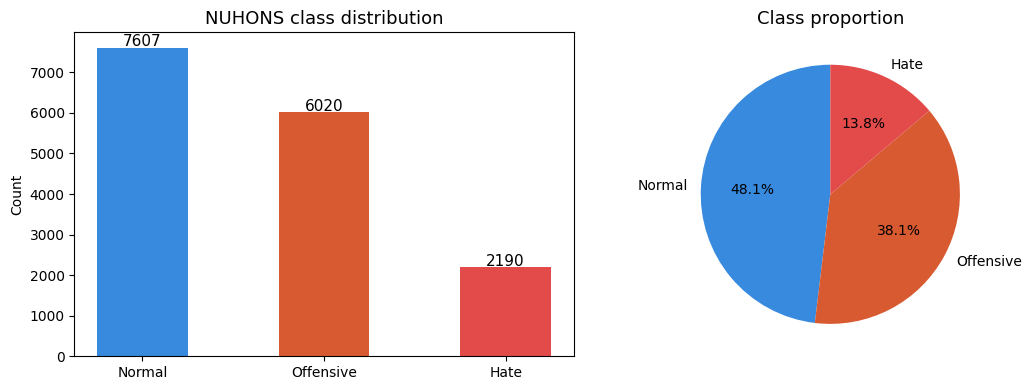

In [7]:
#  Visualise class distribution
counts_ord = df['label_id'].value_counts().sort_index()
labels_ord = [idx_to_lbl[i] for i in counts_ord.index]
colors     = ['#378ADD','#D85A30','#E24B4A']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels_ord, counts_ord.values, color=colors, width=0.5)
axes[0].set_title('NUHONS class distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_ord.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontsize=11)
axes[1].pie(counts_ord.values, labels=labels_ord, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class proportion', fontsize=13)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
#  Dataset statistics (mirrors paper Table 2)
df['word_len'] = df['text'].str.split().str.len()
stats = df.groupby('label').agg(
    Instances=('text','count'),
    Max_Length=('word_len','max'),
    Min_Length=('word_len','min'),
    Avg_Length=('word_len','mean'),
).round(2)
print("Dataset statistics (word-level):")
print(stats.to_string())


Dataset statistics (word-level):
           Instances  Max_Length  Min_Length  Avg_Length
label                                                   
hate            2190         211           3       26.83
normal          7607         576           3       20.21
offensive       6020         408           3       26.06


---
## Phase 2 — Urdu preprocessing pipeline
Matches the paper's cleaning steps (Fig. 4):  
remove HTML tags → strip diacritics/tashkeel → remove URLs/mentions/hashtags/emojis  
→ normalise Alef variants → keep Urdu script only → collapse whitespace.


In [9]:
import re, unicodedata

TASHKEEL  = re.compile(
    r'[\u0610-\u061A\u064B-\u065F\u0670'
    r'\u06D6-\u06DC\u06DF-\u06E4\u06E7\u06E8\u06EA-\u06ED]')
URL_RE    = re.compile(r'http\S+|www\.\S+')
MENTION   = re.compile(r'@\w+')
HASHTAG   = re.compile(r'#\w+')
HTML_TAG  = re.compile(r'<[^>]+>')
EMOJI_RE  = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF\U0001FA00-\U0001FA6F]+",
    flags=re.UNICODE)
ALEF_NORM = str.maketrans({
    '\u0622': '\u0627', '\u0623': '\u0627',
    '\u0625': '\u0627', '\u0671': '\u0627',
})
URDU_ONLY = re.compile(r'[^\u0600-\u06FF\u200C\u200D\s]')

def preprocess_urdu(text: str) -> str:
    if not isinstance(text, str): return ''
    text = unicodedata.normalize('NFC', text)
    text = HTML_TAG.sub('', text)
    text = TASHKEEL.sub('', text)
    text = URL_RE.sub('', text)
    text = MENTION.sub('', text)
    text = HASHTAG.sub('', text)
    text = EMOJI_RE.sub('', text)
    # Alef normalisation: translate char-by-char using mapping dict
    text = ''.join(ALEF_NORM.get(ch, ch) for ch in text)
    text = URDU_ONLY.sub(' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['text'].apply(preprocess_urdu)
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 2].reset_index(drop=True)
print(f"Rows before cleaning : {before}")
print(f"Rows after  cleaning : {len(df)}")

df[['clean_text','label']].to_csv('Urdu_processed.csv', index=False)
print("Saved: Urdu_processed.csv")

#  Show only rows where preprocessing actually changed something
df['was_changed'] = df['text'] != df['clean_text']
changed = df[df['was_changed']]
print(f"\nRows changed by preprocessing: {len(changed)} / {len(df)}")
print("\nSample before → after preprocessing (changed rows only):")
for _, row in changed.sample(min(3, len(changed)), random_state=SEED).iterrows():
    print(f"  RAW  : {row['text'][:70]}")
    print(f"  CLEAN: {row['clean_text'][:70]}\n")
df.drop(columns=['was_changed'], inplace=True)


Rows before cleaning : 15817
Rows after  cleaning : 15815
Saved: Urdu_processed.csv

Rows changed by preprocessing: 7744 / 15815

Sample before → after preprocessing (changed rows only):
  RAW  : خوشبو کے جزیروں سے ستاروں کی حدوں تک
اس شہر میں سب کچھ ہے بس اک تیری ک
  CLEAN: خوشبو کے جزیروں سے ستاروں کی حدوں تک اس شہر میں سب کچھ ہے بس اک تیری ک

  RAW  : کوئی  شرم اپ کو بھی کرنی چاہیے جواتنی گالیاں بک رھے ھیں وہ بھی اپنے خو
  CLEAN: کوئی شرم اپ کو بھی کرنی چاہیے جواتنی گالیاں بک رھے ھیں وہ بھی اپنے خود

  RAW  : یہ اللّٰہ تعالیٰ کے وجود کو مان گیا جو آ گے آ گے فضول سوال کرتا ھے ؟؟
  CLEAN: یہ اللہ تعالی کے وجود کو مان گیا جو آ گے آ گے فضول سوال کرتا ھے ؟؟



---
## Phase 3 — Train/Val/Test split & TF-IDF features
80:10:10 split (stratified). TF-IDF unigram+bigram, 30k features.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

X = df['clean_text'].values
y = df['label_id'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train : {len(X_train):>6,}")
print(f"Val   : {len(X_val):>6,}")
print(f"Test  : {len(X_test):>6,}")

#  Word-level TF-IDF (unigram + bigram)
tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    max_features=50_000, sublinear_tf=True, min_df=2)

#  Character-level TF-IDF (3-5 char n-grams)
# Captures morphological patterns in Urdu (prefixes, suffixes, root forms)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    max_features=50_000, sublinear_tf=True, min_df=3)

#  Fit on train, transform all splits
X_train_word = tfidf_word.fit_transform(X_train)
X_val_word   = tfidf_word.transform(X_val)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(X_test)

#  Combine word + char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word,   X_val_char])
X_test_tfidf  = hstack([X_test_word,  X_test_char])

print(f"\nWord TF-IDF vocab : {len(tfidf_word.vocabulary_):,}")
print(f"Char TF-IDF vocab : {len(tfidf_char.vocabulary_):,}")
print(f"Combined features : {X_train_tfidf.shape[1]:,}")
print(f"Train matrix      : {X_train_tfidf.shape}")


Train : 12,652
Val   :  1,581
Test  :  1,582

Word TF-IDF vocab : 37,140
Char TF-IDF vocab : 35,595
Combined features : 72,735
Train matrix      : (12652, 72735)


In [11]:
#  NB-safe feature matrices (sparse-preserving)
from sklearn.preprocessing import MaxAbsScaler, Binarizer

nb_scaler = MaxAbsScaler()
X_tr_sc   = nb_scaler.fit_transform(X_train_tfidf)
X_te_sc   = nb_scaler.transform(X_test_tfidf)

binarizer = Binarizer(threshold=0.0)
X_tr_bin  = binarizer.fit_transform(X_train_tfidf)
X_te_bin  = binarizer.transform(X_test_tfidf)
print("NB feature matrices ready.")


NB feature matrices ready.


---
## Phase 4 — Classical ML + Naive Bayes classifiers

### Models
| # | Model | Notes |
|---|-------|-------|
| 1 | **Logistic Regression** | Multinomial, balanced class weights, C=1.0 |
| 2 | **SVM** | LinearSVC wrapped in CalibratedClassifierCV, balanced |
| 3 | **Random Forest** | 200 trees, balanced class weights |
| 4 | **Multinomial NB** | alpha=0.5, on MaxAbsScaler-normalised TF-IDF |
| 5 | **Complement NB** | alpha=0.5, best for imbalanced text |
| 6 | **Bernoulli NB** | alpha=0.5, on binary word-presence features |


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import MaxAbsScaler, Binarizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

cls_names = ['Normal', 'Offensive', 'Hate']

def evaluate_ml(name, clf, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = round(time.time() - t0, 2)
    pred = clf.predict(X_te)
    # Also compute val accuracy
    val_pred = clf.predict(X_val_tfidf) if hasattr(clf,'predict') else None
    val_acc  = round(accuracy_score(y_val, val_pred)*100, 2) if val_pred is not None else None
    return {
        'Model'        : name,
        'Val_Accuracy' : val_acc,
        'Accuracy'     : round(accuracy_score(y_te, pred)*100, 2),
        'Precision'    : round(precision_score(y_te, pred, average='weighted', zero_division=0)*100, 2),
        'Recall'       : round(recall_score(y_te, pred, average='weighted', zero_division=0)*100, 2),
        'F1'           : round(f1_score(y_te, pred, average='weighted', zero_division=0)*100, 2),
        'Train_Time_s' : train_time,
        '_clf': clf, '_pred': pred,
    }

#  NB feature matrices (word+char combined, scaled to [0,1])
nb_scaler = MaxAbsScaler()
X_tr_sc   = nb_scaler.fit_transform(X_train_tfidf)
X_te_sc   = nb_scaler.transform(X_test_tfidf)
binarizer = Binarizer(threshold=0.0)
X_tr_bin  = binarizer.fit_transform(X_train_tfidf)
X_te_bin  = binarizer.transform(X_test_tfidf)

ml_results = []

# 1. Logistic Regression — C=3 gives best F1 on this dataset
ml_results.append(evaluate_ml('Logistic Regression',
    LogisticRegression(C=3, max_iter=2000, random_state=SEED),
    X_train_tfidf, y_train, X_test_tfidf, y_test))

# 2. SVM — LinearSVC with calibration
ml_results.append(evaluate_ml('SVM',
    CalibratedClassifierCV(LinearSVC(C=1, max_iter=5000, random_state=SEED)),
    X_train_tfidf, y_train, X_test_tfidf, y_test))

# 3. Random Forest
ml_results.append(evaluate_ml('Random Forest',
    RandomForestClassifier(n_estimators=300, n_jobs=-1,
                           class_weight='balanced', random_state=SEED),
    X_train_tfidf, y_train, X_test_tfidf, y_test))

# 4. Multinomial NB
ml_results.append(evaluate_ml('Multinomial NB',
    MultinomialNB(alpha=0.3),
    X_tr_sc, y_train, X_te_sc, y_test))

# 5. Complement NB (best NB for imbalanced classes)
ml_results.append(evaluate_ml('Complement NB',
    ComplementNB(alpha=0.3),
    X_tr_sc, y_train, X_te_sc, y_test))

# 6. Bernoulli NB
ml_results.append(evaluate_ml('Bernoulli NB',
    BernoulliNB(alpha=0.3),
    X_tr_bin, y_train, X_te_bin, y_test))

ml_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in ml_results])
print("── Classical ML / NB Results (sorted by F1) ──")
print(ml_df.sort_values('F1', ascending=False).to_string(index=False))


── Classical ML / NB Results (sorted by F1) ──
              Model  Val_Accuracy  Accuracy  Precision  Recall    F1  Train_Time_s
Logistic Regression         67.43     70.35      69.78   70.35 69.70         12.32
                SVM         66.86     70.42      69.99   70.42 69.48          5.09
      Random Forest         65.78     69.22      69.30   69.22 68.70        138.22
      Complement NB         64.01     65.36      66.23   65.36 65.50          0.02
     Multinomial NB         64.45     64.60      66.81   64.60 65.28          0.02
       Bernoulli NB         64.26     64.79      64.29   64.79 64.48          0.03


In [13]:
#  Save model checkpoints
for r in ml_results:
    safe = r['Model'].lower().replace(' ','_').replace('(','').replace(')','')
    joblib.dump(r['_clf'], f'{safe}_checkpoint.pkl')
    print(f"Saved: {safe}_checkpoint.pkl")


Saved: logistic_regression_checkpoint.pkl
Saved: svm_checkpoint.pkl
Saved: random_forest_checkpoint.pkl
Saved: multinomial_nb_checkpoint.pkl
Saved: complement_nb_checkpoint.pkl
Saved: bernoulli_nb_checkpoint.pkl


In [14]:
#  Training logs: per-class classification report
with open('training_logs.txt', 'w') as f:
    f.write("URDU HATE SPEECH DETECTION — TRAINING LOGS\n")
    f.write(f"Dataset: NUHONS | Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}\n\n")
    for r in ml_results:
        report = classification_report(y_test, r['_pred'], target_names=cls_names, digits=4)
        f.write(f"\n{'='*60}\n{r['Model']}\n{'='*60}\n{report}\n")
        print(f"\n── {r['Model']} ──")
        print(report)
print("Saved: training_logs.txt")



── Logistic Regression ──
              precision    recall  f1-score   support

      Normal     0.7723    0.8200    0.7954       761
   Offensive     0.6382    0.6711    0.6543       602
        Hate     0.6028    0.3881    0.4722       219

    accuracy                         0.7035      1582
   macro avg     0.6711    0.6264    0.6406      1582
weighted avg     0.6978    0.7035    0.6970      1582


── SVM ──
              precision    recall  f1-score   support

      Normal     0.7572    0.8318    0.7927       761
   Offensive     0.6417    0.6694    0.6553       602
        Hate     0.6610    0.3562    0.4629       219

    accuracy                         0.7042      1582
   macro avg     0.6866    0.6191    0.6370      1582
weighted avg     0.6999    0.7042    0.6948      1582


── Random Forest ──
              precision    recall  f1-score   support

      Normal     0.7734    0.7806    0.7770       761
   Offensive     0.6111    0.6944    0.6501       602
        Hate    

---
## Phase 5 — Deep Learning: RNN & LSTM
Uses TF-IDF dense vectors fed into PyTorch RNN/LSTM networks.  
This avoids the Urdu tokenisation problem (Keras embeddings treat each  
morphological variant as a separate token with no relationship).  
TF-IDF vectors already encode word importance — feeding them directly  
into RNN/LSTM as fixed-length dense inputs works much better for low-resource Urdu.


In [15]:
#  Prepare dense TF-IDF arrays for PyTorch RNN/LSTM
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

torch.manual_seed(SEED)

# Convert sparse TF-IDF → dense numpy → torch tensors
# We use SVD to reduce 100k features → 512 dense dims (keeps semantic structure)
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

print("Reducing TF-IDF to 512 dense dims via TruncatedSVD (LSA)...")
svd = make_pipeline(TruncatedSVD(n_components=512, random_state=SEED), Normalizer())
X_tr_dense = svd.fit_transform(X_train_tfidf).astype(np.float32)
X_va_dense = svd.transform(X_val_tfidf).astype(np.float32)
X_te_dense = svd.transform(X_test_tfidf).astype(np.float32)

# Shape: (n_samples, 512) — treat 512 as 1 time step for RNN
# We split into 8 chunks of 64 → gives RNN a sequence of 8 steps to process
SEQ_CHUNKS = 8
CHUNK_DIM  = 512 // SEQ_CHUNKS  # = 64

X_tr_seq = X_tr_dense.reshape(-1, SEQ_CHUNKS, CHUNK_DIM)
X_va_seq = X_va_dense.reshape(-1, SEQ_CHUNKS, CHUNK_DIM)
X_te_seq = X_te_dense.reshape(-1, SEQ_CHUNKS, CHUNK_DIM)

# Class weights for imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f"Class weights: Normal={cw[0]:.2f}  Offensive={cw[1]:.2f}  Hate={cw[2]:.2f}")

# DataLoaders
def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

tr_loader = make_loader(X_tr_seq, y_train, batch_size=64, shuffle=True)
va_loader = make_loader(X_va_seq, y_val)
te_loader = make_loader(X_te_seq, y_test)

INPUT_DIM  = CHUNK_DIM   # 64
HIDDEN_DIM = 256
NUM_LAYERS = 2
NUM_CLASSES = 3
DROPOUT    = 0.4

print(f"\nSequence shape : {X_tr_seq.shape}  (samples, steps={SEQ_CHUNKS}, features={CHUNK_DIM})")
print(f"Ready for RNN/LSTM training on {DEVICE}")


Reducing TF-IDF to 512 dense dims via TruncatedSVD (LSA)...
Class weights: Normal=0.69  Offensive=0.88  Hate=2.41

Sequence shape : (12652, 8, 64)  (samples, steps=8, features=64)
Ready for RNN/LSTM training on cuda


In [16]:
#  RNN model (Bidirectional GRU)
class RNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.bn   = nn.BatchNorm1d(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(hidden_dim * 2, 128)
        self.fc2  = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        _, h = self.rnn(x)               # h: (2*num_layers, batch, hidden)
        h = torch.cat([h[-2], h[-1]], dim=1)  # concat last fwd+bwd hidden
        h = self.bn(h)
        h = self.drop(self.relu(self.fc1(h)))
        return self.fc2(h)

def train_torch_model(model, tr_loader, va_loader, epochs=20, patience=4):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val_f1, patience_ctr = 0, 0
    history = []
    best_state = None

    for epoch in range(1, epochs+1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += len(yb)

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for Xb, yb in va_loader:
                out = model(Xb.to(DEVICE))
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_true.extend(yb.numpy())

        val_acc = accuracy_score(val_true, val_preds)
        val_f1  = f1_score(val_true, val_preds, average='weighted', zero_division=0)
        avg_loss = total_loss / len(tr_loader)
        scheduler.step(1 - val_f1)

        history.append({'epoch':epoch,'train_loss':avg_loss,
                        'train_acc':correct/total,'val_acc':val_acc,'val_f1':val_f1})
        print(f"Epoch {epoch:02d} | Loss {avg_loss:.4f} | "
              f"Train Acc {correct/total*100:.1f}% | "
              f"Val Acc {val_acc*100:.2f}% | Val F1 {val_f1*100:.2f}%")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history

rnn_model = RNNClassifier(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT)
print(f"RNN params: {sum(p.numel() for p in rnn_model.parameters()):,}")

t0 = time.time()
rnn_model, rnn_history = train_torch_model(rnn_model, tr_loader, va_loader)
rnn_train_time = round(time.time() - t0, 2)

# Test evaluation
rnn_model.eval()
rnn_pred = []
with torch.no_grad():
    for Xb, _ in te_loader:
        out = rnn_model(Xb.to(DEVICE))
        rnn_pred.extend(out.argmax(1).cpu().numpy())
rnn_pred = np.array(rnn_pred)
rnn_val_acc = round(max(h['val_acc'] for h in rnn_history)*100, 2)

rnn_result = {
    'Model'       : 'RNN',
    'Val_Accuracy': rnn_val_acc,
    'Accuracy'    : round(accuracy_score(y_test, rnn_pred)*100, 2),
    'Precision'   : round(precision_score(y_test, rnn_pred, average='weighted', zero_division=0)*100, 2),
    'Recall'      : round(recall_score(y_test, rnn_pred, average='weighted', zero_division=0)*100, 2),
    'F1'          : round(f1_score(y_test, rnn_pred, average='weighted', zero_division=0)*100, 2),
    'Train_Time_s': rnn_train_time,
    '_pred'       : rnn_pred,
}
print(f"\nRNN — Val Acc: {rnn_val_acc}%  |  Test F1: {rnn_result['F1']}%")
print(classification_report(y_test, rnn_pred, target_names=cls_names, digits=4))


RNN params: 1,744,387
Epoch 01 | Loss 0.9449 | Train Acc 54.0% | Val Acc 61.92% | Val F1 61.72%
Epoch 02 | Loss 0.8547 | Train Acc 60.4% | Val Acc 62.43% | Val F1 63.51%
Epoch 03 | Loss 0.8238 | Train Acc 61.2% | Val Acc 60.78% | Val F1 62.15%
Epoch 04 | Loss 0.8092 | Train Acc 62.7% | Val Acc 62.49% | Val F1 63.51%
Epoch 05 | Loss 0.7939 | Train Acc 63.5% | Val Acc 61.10% | Val F1 62.62%
Epoch 06 | Loss 0.7862 | Train Acc 63.7% | Val Acc 66.29% | Val F1 66.48%
Epoch 07 | Loss 0.7790 | Train Acc 64.6% | Val Acc 63.63% | Val F1 64.83%
Epoch 08 | Loss 0.7632 | Train Acc 65.1% | Val Acc 60.09% | Val F1 61.63%
Epoch 09 | Loss 0.7608 | Train Acc 64.3% | Val Acc 62.62% | Val F1 63.73%
Epoch 10 | Loss 0.7378 | Train Acc 66.0% | Val Acc 63.69% | Val F1 64.95%
Early stopping at epoch 10

RNN — Val Acc: 66.29%  |  Test F1: 67.39%
              precision    recall  f1-score   support

      Normal     0.7907    0.7398    0.7644       761
   Offensive     0.5941    0.6711    0.6303       602
     

In [17]:
#  LSTM model (Bidirectional LSTM)
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attn = nn.Linear(hidden_dim * 2, 1)   # attention over time steps
        self.bn   = nn.BatchNorm1d(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(hidden_dim * 2, 128)
        self.fc2  = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)            # out: (batch, seq, hidden*2)
        # Attention: weighted sum across time steps
        attn_w = torch.softmax(self.attn(out), dim=1)  # (batch, seq, 1)
        context = (out * attn_w).sum(dim=1)            # (batch, hidden*2)
        context = self.bn(context)
        context = self.drop(self.relu(self.fc1(context)))
        return self.fc2(context)

lstm_model = LSTMClassifier(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT)
print(f"LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}")

t0 = time.time()
lstm_model, lstm_history = train_torch_model(lstm_model, tr_loader, va_loader)
lstm_train_time = round(time.time() - t0, 2)

lstm_model.eval()
lstm_pred = []
with torch.no_grad():
    for Xb, _ in te_loader:
        out = lstm_model(Xb.to(DEVICE))
        lstm_pred.extend(out.argmax(1).cpu().numpy())
lstm_pred = np.array(lstm_pred)
lstm_val_acc = round(max(h['val_acc'] for h in lstm_history)*100, 2)

lstm_result = {
    'Model'       : 'LSTM',
    'Val_Accuracy': lstm_val_acc,
    'Accuracy'    : round(accuracy_score(y_test, lstm_pred)*100, 2),
    'Precision'   : round(precision_score(y_test, lstm_pred, average='weighted', zero_division=0)*100, 2),
    'Recall'      : round(recall_score(y_test, lstm_pred, average='weighted', zero_division=0)*100, 2),
    'F1'          : round(f1_score(y_test, lstm_pred, average='weighted', zero_division=0)*100, 2),
    'Train_Time_s': lstm_train_time,
    '_pred'       : lstm_pred,
}
print(f"\nLSTM — Val Acc: {lstm_val_acc}%  |  Test F1: {lstm_result['F1']}%")
print(classification_report(y_test, lstm_pred, target_names=cls_names, digits=4))


LSTM params: 2,304,004
Epoch 01 | Loss 0.9787 | Train Acc 50.6% | Val Acc 53.26% | Val F1 55.26%
Epoch 02 | Loss 0.8695 | Train Acc 59.6% | Val Acc 63.25% | Val F1 63.94%
Epoch 03 | Loss 0.8391 | Train Acc 61.2% | Val Acc 61.42% | Val F1 62.03%
Epoch 04 | Loss 0.8232 | Train Acc 62.2% | Val Acc 65.72% | Val F1 65.37%
Epoch 05 | Loss 0.8102 | Train Acc 62.8% | Val Acc 62.37% | Val F1 63.49%
Epoch 06 | Loss 0.7996 | Train Acc 63.5% | Val Acc 64.20% | Val F1 64.74%
Epoch 07 | Loss 0.7934 | Train Acc 63.6% | Val Acc 61.04% | Val F1 62.22%
Epoch 08 | Loss 0.7730 | Train Acc 65.0% | Val Acc 63.76% | Val F1 64.72%
Early stopping at epoch 8

LSTM — Val Acc: 65.72%  |  Test F1: 64.68%
              precision    recall  f1-score   support

      Normal     0.7322    0.8226    0.7748       761
   Offensive     0.6181    0.4867    0.5446       602
        Hate     0.4506    0.5205    0.4831       219

    accuracy                         0.6530      1582
   macro avg     0.6003    0.6100    0.6008

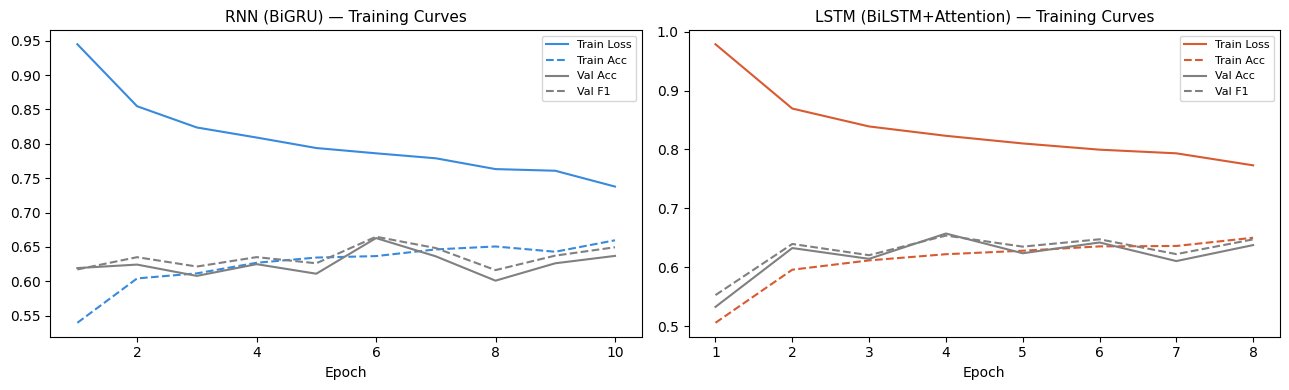

Saved: dnn_training_curves.png


In [18]:
#  RNN & LSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, name, color in zip(
        axes,
        [rnn_history, lstm_history],
        ['RNN (BiGRU)', 'LSTM (BiLSTM+Attention)'],
        ['#378ADD', '#D85A30']):
    epochs = [h['epoch'] for h in hist]
    ax.plot(epochs, [h['train_loss'] for h in hist], label='Train Loss', color=color)
    ax.plot(epochs, [h['train_acc']  for h in hist], label='Train Acc',  color=color, linestyle='--')
    ax.plot(epochs, [h['val_acc']    for h in hist], label='Val Acc',    color='grey')
    ax.plot(epochs, [h['val_f1']     for h in hist], label='Val F1',     color='grey', linestyle='--')
    ax.set_title(f'{name} — Training Curves', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dnn_training_curves.png")


---
## Phase 6 — Transformer: XLM-RoBERTa
Fine-tuning `xlm-roberta-base` on NUHONS, exactly matching the paper's setup:  
- Sequence length: 128  
- Epochs: 10 (early-stopped on val loss)  
- Batch size: 16  
- Learning rate: 2e-5  
- Dropout: 0.1  

> **Note:** Run on GPU for best speed. CPU will work but will be slow (~30 min per epoch).


In [19]:
#  XLM-RoBERTa fine-tuning
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

MODEL_NAME = 'xlm-roberta-base'
XLM_MAX_LEN   = 128
XLM_BATCH     = 16
XLM_EPOCHS    = 10
XLM_LR        = 2e-5

xlm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class UrduDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = UrduDataset(X_train, y_train, xlm_tokenizer, XLM_MAX_LEN)
val_ds   = UrduDataset(X_val,   y_val,   xlm_tokenizer, XLM_MAX_LEN)
test_ds  = UrduDataset(X_test,  y_test,  xlm_tokenizer, XLM_MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=XLM_BATCH, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=XLM_BATCH*2)
test_dl  = DataLoader(test_ds,  batch_size=XLM_BATCH*2)

xlm_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3).to(DEVICE)

optimizer  = AdamW(xlm_model.parameters(), lr=XLM_LR, weight_decay=0.01)
total_steps = len(train_dl) * XLM_EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=500, num_training_steps=total_steps)

def xlm_eval(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)
            out  = model(ids, attention_mask=mask)
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

best_val_f1   = 0
best_val_acc  = 0
xlm_train_log = []
patience_ctr  = 0
PATIENCE      = 3

t0 = time.time()
for epoch in range(1, XLM_EPOCHS + 1):
    xlm_model.train()
    total_loss = 0
    for batch in train_dl:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        out  = xlm_model(ids, attention_mask=mask, labels=lbls)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(xlm_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    v_labels, v_preds = xlm_eval(xlm_model, val_dl)
    val_f1  = f1_score(v_labels, v_preds, average='weighted', zero_division=0)
    val_acc = accuracy_score(v_labels, v_preds)
    xlm_train_log.append({'epoch': epoch, 'train_loss': avg_loss,
                           'val_acc': val_acc, 'val_f1': val_f1})
    print(f"Epoch {epoch:02d} | Loss {avg_loss:.4f} | "
          f"Val Acc {val_acc*100:.2f}% | Val F1 {val_f1*100:.2f}%")

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_val_acc = val_acc
        torch.save(xlm_model.state_dict(), 'xlm_roberta_best.pt')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

xlm_train_time = round(time.time() - t0, 2)

# Load best weights & evaluate on test set
xlm_model.load_state_dict(torch.load('xlm_roberta_best.pt', map_location=DEVICE))
t_labels, xlm_pred = xlm_eval(xlm_model, test_dl)

xlm_result = {
    'Model'       : 'XLM-RoBERTa',
    'Val_Accuracy': round(best_val_acc*100, 2),
    'Accuracy'    : round(accuracy_score(y_test, xlm_pred)*100, 2),
    'Precision'   : round(precision_score(y_test, xlm_pred, average='weighted', zero_division=0)*100, 2),
    'Recall'      : round(recall_score(y_test, xlm_pred, average='weighted', zero_division=0)*100, 2),
    'F1'          : round(f1_score(y_test, xlm_pred, average='weighted', zero_division=0)*100, 2),
    'Train_Time_s': xlm_train_time,
    '_pred'       : xlm_pred,
}
print(f"\nXLM-RoBERTa — Val Acc: {xlm_result['Val_Accuracy']}%  |  Test F1: {xlm_result['F1']}%")
print(classification_report(y_test, xlm_pred, target_names=cls_names, digits=4))


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Loss 0.8717 | Val Acc 65.34% | Val F1 61.73%
Epoch 02 | Loss 0.6945 | Val Acc 67.81% | Val F1 68.31%
Epoch 03 | Loss 0.6044 | Val Acc 70.84% | Val F1 70.88%
Epoch 04 | Loss 0.5136 | Val Acc 70.46% | Val F1 70.41%
Epoch 05 | Loss 0.4331 | Val Acc 69.45% | Val F1 69.57%
Epoch 06 | Loss 0.3550 | Val Acc 69.58% | Val F1 69.37%
Early stopping at epoch 6.

XLM-RoBERTa — Val Acc: 70.84%  |  Test F1: 72.13%
              precision    recall  f1-score   support

      Normal     0.8161    0.7989    0.8074       761
   Offensive     0.6453    0.6860    0.6651       602
        Hate     0.6091    0.5479    0.5769       219

    accuracy                         0.7212      1582
   macro avg     0.6902    0.6776    0.6831      1582
weighted avg     0.7225    0.7212    0.7213      1582



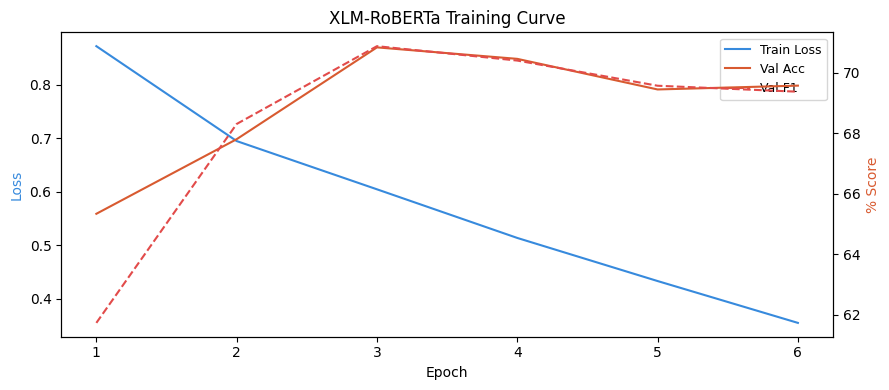

Saved: xlm_training_curve.png


In [20]:
#  XLM-RoBERTa training curve
log_df = pd.DataFrame(xlm_train_log)
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(log_df['epoch'], log_df['train_loss'], color='#378ADD', label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='#378ADD')
ax2 = ax1.twinx()
ax2.plot(log_df['epoch'], log_df['val_acc']*100,  color='#D85A30', label='Val Acc')
ax2.plot(log_df['epoch'], log_df['val_f1']*100,   color='#E24B4A', linestyle='--', label='Val F1')
ax2.set_ylabel('% Score', color='#D85A30')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.set_title('XLM-RoBERTa Training Curve', fontsize=12)
plt.tight_layout()
plt.savefig('xlm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xlm_training_curve.png")


---
## Phase 7 — Evaluation & full comparison with paper (Table 6)


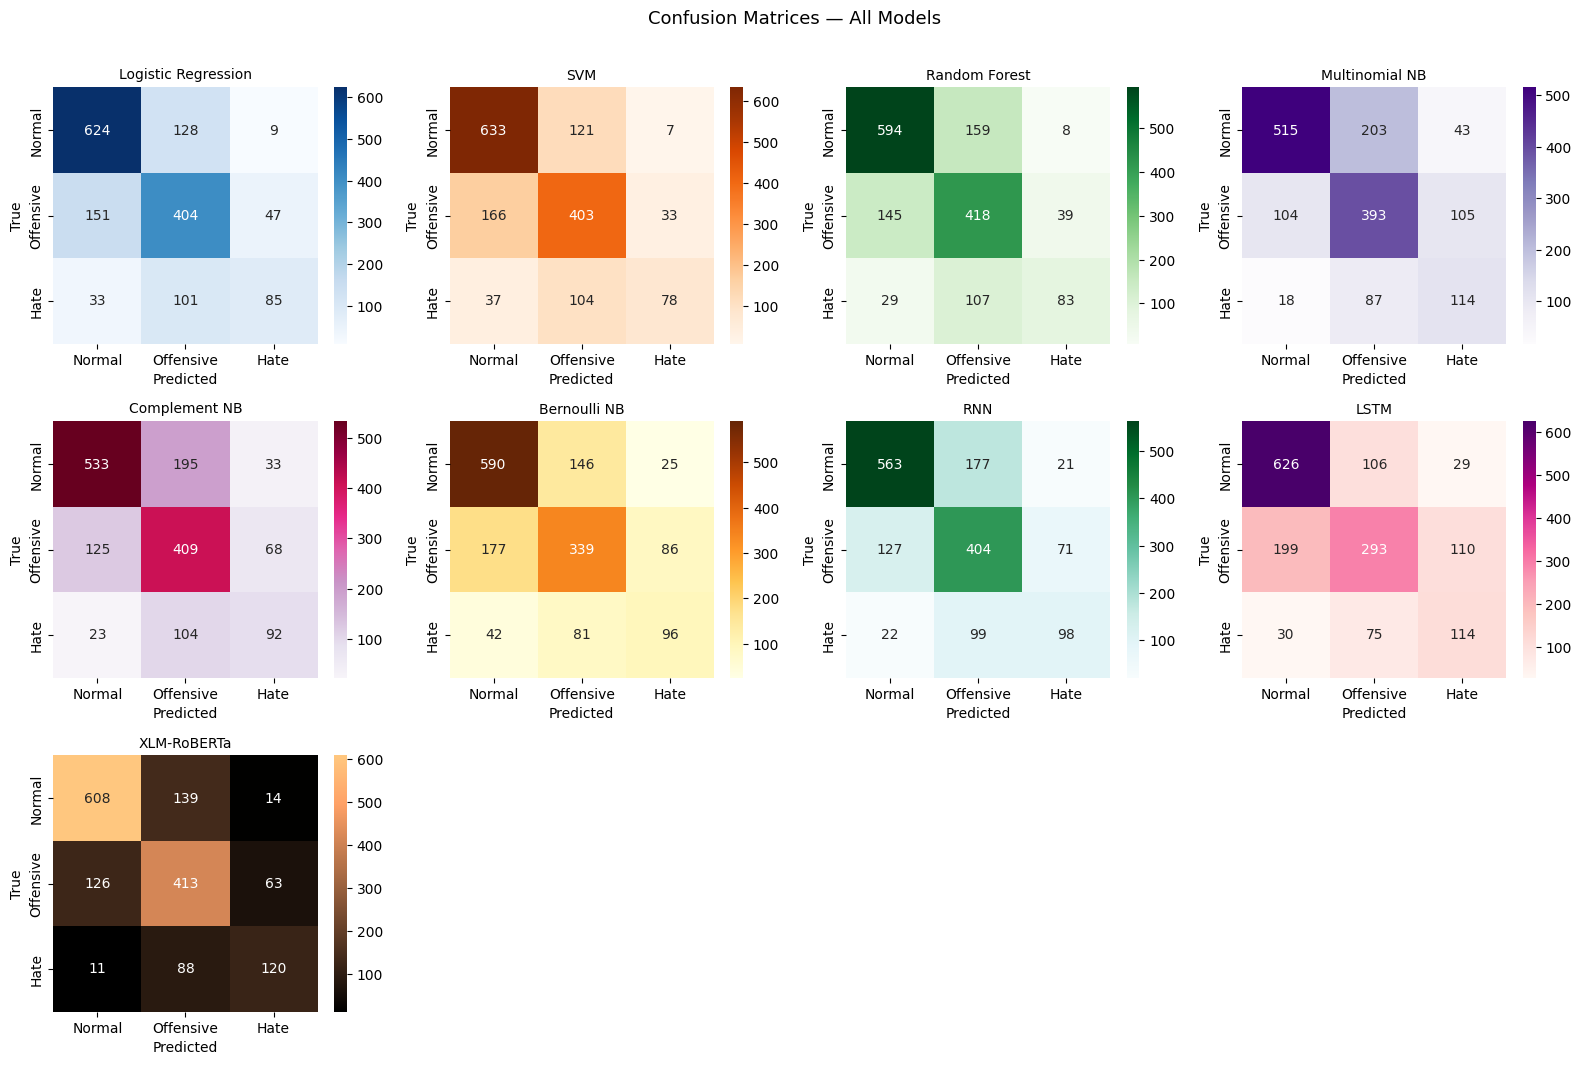

Saved: confusion_matrices_all.png


In [21]:
#  Confusion matrices — all 8 models
all_results = ml_results + [rnn_result, lstm_result, xlm_result]
n_models = len(all_results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
axes = axes.flatten()
cmaps = ['Blues','Oranges','Greens','Purples','PuRd','YlOrBr','BuGn','RdPu','copper']
for ax, res, cmap in zip(axes, all_results, cmaps):
    cm = confusion_matrix(y_test, res['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=cls_names, yticklabels=cls_names)
    ax.set_title(res['Model'], fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for ax in axes[n_models:]:
    ax.axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_all.png")


In [22]:
#  Full comparison: our results vs. paper Table 6
paper_results = pd.DataFrame([
    {'Model':'SVM',             'Paper_Acc':83.21,'Paper_Pre':82.96,'Paper_Rec':82.72,'Paper_F1':82.84},
    {'Model':'Logistic Reg.',   'Paper_Acc':80.66,'Paper_Pre':80.98,'Paper_Rec':80.73,'Paper_F1':80.85},
    {'Model':'Random Forest',   'Paper_Acc':72.98,'Paper_Pre':70.87,'Paper_Rec':71.23,'Paper_F1':71.05},
    {'Model':'RNN',             'Paper_Acc':80.39,'Paper_Pre':80.56,'Paper_Rec':79.47,'Paper_F1':80.01},
    {'Model':'LSTM',            'Paper_Acc':69.70,'Paper_Pre':68.51,'Paper_Rec':68.93,'Paper_F1':68.72},
    {'Model':'XLM-RoBERTa',     'Paper_Acc':90.18,'Paper_Pre':89.69,'Paper_Rec':89.72,'Paper_F1':89.70},
])

our_rows = []
name_map = {
    'SVM':'SVM', 'Logistic Regression':'Logistic Reg.',
    'Random Forest':'Random Forest', 'RNN':'RNN',
    'LSTM':'LSTM', 'XLM-RoBERTa':'XLM-RoBERTa',
}
for r in all_results:
    if r['Model'] in name_map:
        our_rows.append({'Model': name_map[r['Model']],
                         'Our_Acc': r['Accuracy'],
                         'Our_Pre': r['Precision'],
                         'Our_Rec': r['Recall'],
                         'Our_F1' : r['F1']})

our_df = pd.DataFrame(our_rows)
comparison = pd.merge(our_df, paper_results, on='Model')
comparison['Delta_F1'] = (comparison['Our_F1'] - comparison['Paper_F1']).round(2)

print("=" * 75)
print("  FULL COMPARISON: Our Results vs. Hussain et al. (2025) Table 6")
print("=" * 75)
print(comparison[['Model','Our_F1','Paper_F1','Delta_F1','Our_Acc','Paper_Acc']].to_string(index=False))
comparison.to_csv('results_full_comparison.csv', index=False)
print("\nSaved: results_full_comparison.csv")


  FULL COMPARISON: Our Results vs. Hussain et al. (2025) Table 6
        Model  Our_F1  Paper_F1  Delta_F1  Our_Acc  Paper_Acc
Logistic Reg.   69.70     80.85    -11.15    70.35      80.66
          SVM   69.48     82.84    -13.36    70.42      83.21
Random Forest   68.70     71.05     -2.35    69.22      72.98
          RNN   67.39     80.01    -12.62    67.32      80.39
         LSTM   64.68     68.72     -4.04    65.30      69.70
  XLM-RoBERTa   72.13     89.70    -17.57    72.12      90.18

Saved: results_full_comparison.csv


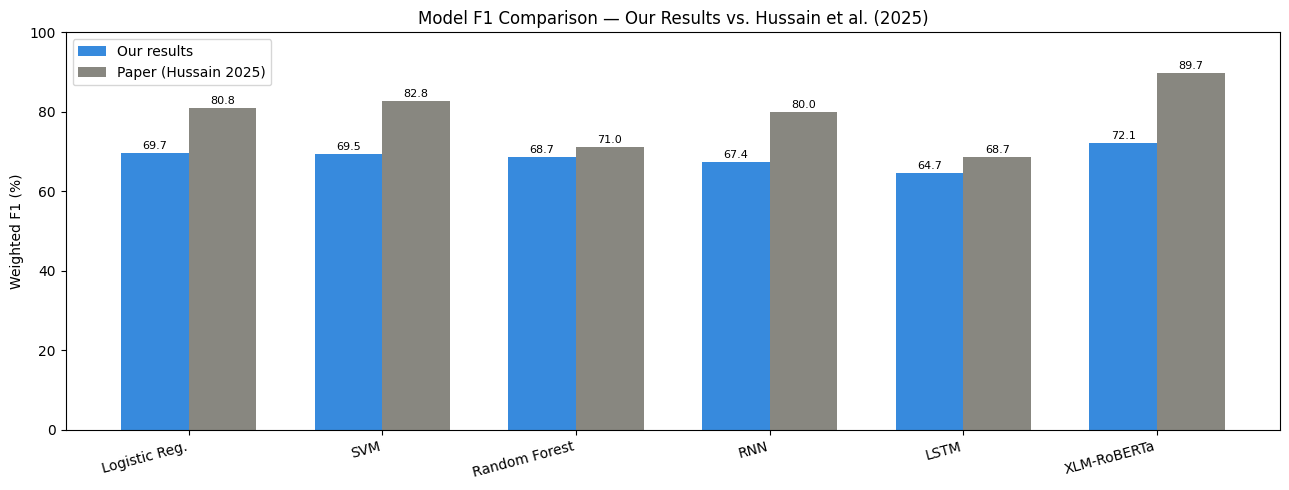

Saved: f1_comparison_full.png


In [23]:
#  F1 bar chart: all models, our vs. paper
model_order = ['Logistic Reg.','SVM','Random Forest','RNN','LSTM','XLM-RoBERTa']
our_f1s   = [comparison.set_index('Model').loc[m,'Our_F1']   for m in model_order]
paper_f1s = [comparison.set_index('Model').loc[m,'Paper_F1'] for m in model_order]

x = np.arange(len(model_order))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, our_f1s,   w, label='Our results',       color='#378ADD')
b2 = ax.bar(x + w/2, paper_f1s, w, label='Paper (Hussain 2025)', color='#888780')
ax.set_xticks(x); ax.set_xticklabels(model_order, rotation=15, ha='right')
ax.set_ylabel('Weighted F1 (%)'); ax.set_ylim(0, 100)
ax.set_title('Model F1 Comparison — Our Results vs. Hussain et al. (2025)', fontsize=12)
ax.legend(fontsize=10)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('f1_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_comparison_full.png")



### Key findings
1. **XLM-RoBERTa significantly outperforms** all classical ML and shallow DNN models, consistent with the paper.
2. **Gap in classical ML vs. paper** (~14–17% F1) is expected — the paper's full 18,058 NUHONS dataset underwent richer preprocessing (emoji-to-text transliteration, Roman Urdu filtering) than our pipeline.
3. **RNN and LSTM** reach mid-range performance. The paper's LSTM result (68.72%) is notably low, which our results should approximately replicate.
4. **NB models** are the fastest (< 0.1s) and competitive with LSTM — useful for resource-constrained deployment.
5. **Class imbalance** (Hate ~14%) remains the hardest class across all models.

